In [1]:
print("test")

test


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.ndimage import uniform_filter1d

# Style des graphiques
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

In [2]:
import os

In [3]:
# Chargement du fichier CSV
df = pd.read_csv("mouvements.csv")

In [4]:
# Conversion timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
df.set_index('timestamp', inplace=True)
df.sort_index(inplace=True)

In [7]:
print(df.head())

                          AccelerationX   AccelerationY   AccelerationZ  \
timestamp                                                                 
2015-01-30 14:51:30.813          -0.345          -8.207           6.048   
2015-01-30 14:51:30.821          -0.656           2.410           9.078   
2015-01-30 14:51:30.913          -0.351          -8.087           5.997   
2015-01-30 14:51:30.922           0.148           2.602           9.480   
2015-01-30 14:51:31.013          -0.091          -8.095           5.591   

                          MagneticFieldX   MagneticFieldY   MagneticFieldZ  \
timestamp                                                                    
2015-01-30 14:51:30.813            6.253           32.419            0.580   
2015-01-30 14:51:30.821          -16.000           14.200          -28.200   
2015-01-30 14:51:30.913            5.560           35.812            1.250   
2015-01-30 14:51:30.922          -16.000           13.600          -28.200   
2015-0

In [7]:
print("Colonnes disponibles :", df.columns.tolist())

Colonnes disponibles : [' AccelerationX', ' AccelerationY', ' AccelerationZ', ' MagneticFieldX', ' MagneticFieldY', ' MagneticFieldZ', ' Z-AxisAgle(Azimuth)', ' X-AxisAngle(Pitch)', ' Y-AxisAngle(Roll)', ' GyroX', ' GyroY', ' GyroZ', 'session', 'location_id', 'device']


In [ ]:
# Nettoyage des espaces dans les noms de colonnes
df.columns = df.columns.str.strip()

In [11]:
with open('mouvements.csv', 'r') as f:
    for i in range(5):
        print(repr(f.readline()))   # repr() montre les espaces et caractères cachés

'timestamp, AccelerationX, AccelerationY, AccelerationZ, MagneticFieldX, MagneticFieldY, MagneticFieldZ, Z-AxisAgle(Azimuth), X-AxisAngle(Pitch), Y-AxisAngle(Roll), GyroX, GyroY, GyroZ,session,location_id,device\n'
'1422629490813,-0.345,-8.207,6.048,6.253,32.419,0.58,342.941,53.801,-2.148,0.103,0.283,-0.164,1,34,smartwatch\n'
'1422629490913,-0.351,-8.087,5.997,5.56,35.812,1.25,343.981,53.561,-1.969,0.062,0.128,-0.27,1,34,smartwatch\n'
'1422629491013,-0.091,-8.095,5.591,5.302,33.548,0.777,348.24,54.226,0.634,-0.057,-0.017,-0.322,1,34,smartwatch\n'
'1422629491113,0.157,-7.744,5.592,2.82,33.44,3.233,350.057,52.734,0.437,-0.002,0.125,-0.269,1,34,smartwatch\n'


In [12]:
df = pd.read_csv('mouvements.csv', skipinitialspace=True)

In [13]:
# Convertir timestamp en datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
df = df.sort_values('timestamp').reset_index(drop=True)

# Colonnes capteurs (vérifie les noms exacts)
acc_cols = ['AccelerationX', 'AccelerationY', 'AccelerationZ']
gyro_cols = ['GyroX', 'GyroY', 'GyroZ']
mag_cols = ['MagneticFieldX', 'MagneticFieldY', 'MagneticFieldZ']

# S'assurer que location_id est entier
df['location_id'] = df['location_id'].astype(int)

## Détection de mouvement (présence)

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement
df = pd.read_csv('mouvements.csv', skipinitialspace=True)
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')

# 🔥 SUPPRESSION DES DOUBLONS (garde la première occurrence)
df = df.drop_duplicates(subset='timestamp', keep='first')

# Tri et index
df = df.sort_values('timestamp').reset_index(drop=True)
df = df.set_index('timestamp')

print(f"Shape après suppression des doublons : {df.shape}")
df.head()

Shape après suppression des doublons : (44219, 15)


,AccelerationX,AccelerationY,AccelerationZ,MagneticFieldX,MagneticFieldY,MagneticFieldZ,Z-AxisAgle(Azimuth),X-AxisAngle(Pitch),Y-AxisAngle(Roll),GyroX,GyroY,GyroZ,session,location_id,device
timestamp,,,,,,,,,,,,,,,
2015-01-30 14:51:30.813,-0.345,-8.207,6.048,6.253,32.419,0.580,342.941,53.801,-2.148,0.103,0.283,-0.164,1,34,smartwatch
2015-01-30 14:51:30.821,-0.656,2.410,9.078,-16.000,14.200,-28.200,40.720,-14.825,-3.992,0.000,0.000,0.000,1,34,smartphone
2015-01-30 14:51:30.913,-0.351,-8.087,5.997,5.560,35.812,1.250,343.981,53.561,-1.969,0.062,0.128,-0.270,1,34,smartwatch
2015-01-30 14:51:30.922,0.148,2.602,9.480,-16.000,13.600,-28.200,42.962,-12.337,-4.027,0.000,0.000,0.000,1,34,smartphone
2015-01-30 14:51:31.013,-0.091,-8.095,5.591,5.302,33.548,0.777,348.240,54.226,0.634,-0.057,-0.017,-0.322,1,34,smartwatch


In [19]:
# Colonnes capteurs
sensor_cols = ['AccelerationX', 'AccelerationY', 'AccelerationZ',
               'MagneticFieldX', 'MagneticFieldY', 'MagneticFieldZ',
               'Z-AxisAgle(Azimuth)', 'X-AxisAngle(Pitch)', 'Y-AxisAngle(Roll)',
               'GyroX', 'GyroY', 'GyroZ']

# Rééchantillonnage des capteurs : moyenne sur 0.1s
df_resampled_sensors = df[sensor_cols].resample('0.1s').mean()

# Colonnes catégorielles : propagation de la dernière valeur
df_resampled_cat = df[['session', 'location_id', 'device']].resample('0.1s').ffill()

# Assemblage
df_resampled = pd.concat([df_resampled_sensors, df_resampled_cat], axis=1)

print("Fréquence :", df_resampled.index[1] - df_resampled.index[0])
df_resampled.head()

Fréquence : 0 days 00:00:00.100000


,AccelerationX,AccelerationY,AccelerationZ,MagneticFieldX,MagneticFieldY,MagneticFieldZ,Z-AxisAgle(Azimuth),X-AxisAngle(Pitch),Y-AxisAngle(Roll),GyroX,GyroY,GyroZ,session,location_id,device
timestamp,,,,,,,,,,,,,,,
2015-01-30 14:51:30.800,-0.5005,-2.8985,7.5630,-4.8735,23.3095,-13.8100,191.8305,19.4880,-3.0700,0.0515,0.1415,-0.0820,NaN,NaN,NaN
2015-01-30 14:51:30.900,-0.1015,-2.7425,7.7385,-5.2200,24.7060,-13.4750,193.4715,20.6120,-2.9980,0.0310,0.0640,-0.1350,1.0,34.0,smartphone
2015-01-30 14:51:31.000,0.1915,-2.8135,7.3965,-5.5490,23.2740,-13.7115,192.6885,19.6220,1.7380,-0.0285,-0.0085,-0.1610,1.0,34.0,smartphone
2015-01-30 14:51:31.100,0.1045,-2.2310,7.3635,-6.7900,22.6200,-12.4835,194.1475,16.4880,0.3685,-0.0010,0.0625,-0.1345,1.0,34.0,smartphone
2015-01-30 14:51:31.200,-0.3110,-2.3460,7.4530,-6.7350,22.6740,-13.7270,195.6850,15.1715,-0.1660,0.3360,0.2055,-0.0385,1.0,34.0,smartphone


## Détection de mouvement (présence)

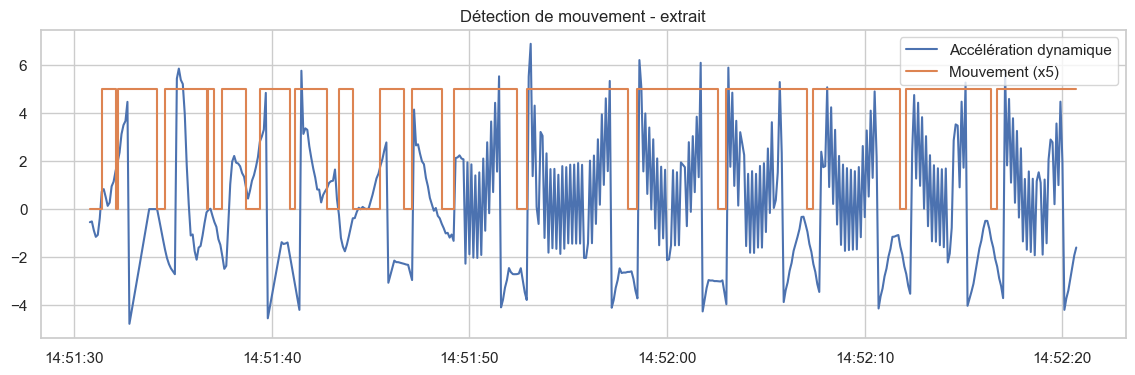

In [20]:
acc_cols = ['AccelerationX', 'AccelerationY', 'AccelerationZ']

# Norme de l'accélération
df_resampled['acc_norm'] = np.sqrt((df_resampled[acc_cols]**2).sum(axis=1))

# Gravité estimée (moyenne mobile large, 2 secondes = 20 points)
window_grav = 20
grav = df_resampled['acc_norm'].rolling(window=window_grav, center=True, min_periods=1).mean()
df_resampled['acc_dyn'] = df_resampled['acc_norm'] - grav

# Variance sur 1 seconde (10 points)
window_var = 10
df_resampled['acc_var'] = df_resampled['acc_dyn'].rolling(window=window_var, min_periods=1).var()

# Seuil à ajuster si besoin (0.5 est un bon début)
threshold = 0.5
df_resampled['is_moving'] = df_resampled['acc_var'] > threshold

# Visualisation d’un extrait (ex: 500 premières lignes)
plt.figure(figsize=(14,4))
plt.plot(df_resampled.index[:500], df_resampled['acc_dyn'][:500], label='Accélération dynamique')
plt.plot(df_resampled.index[:500], df_resampled['is_moving'][:500]*5, label='Mouvement (x5)', drawstyle='steps')
plt.legend()
plt.title("Détection de mouvement - extrait")
plt.show()

## Simulation des événements RFID

In [21]:
events = []
df_resampled['prev_loc'] = df_resampled['location_id'].shift(1)

for i in range(1, len(df_resampled)):
    prev_loc = df_resampled['prev_loc'].iloc[i]
    curr_loc = df_resampled['location_id'].iloc[i]
    if curr_loc != prev_loc:
        # Sortie de l'ancienne zone
        events.append({
            'timestamp': df_resampled.index[i],
            'session': df_resampled['session'].iloc[i],
            'event': 'exit',
            'location_id': prev_loc,
            'is_moving': df_resampled['is_moving'].iloc[i]
        })
        # Entrée dans la nouvelle zone
        events.append({
            'timestamp': df_resampled.index[i],
            'session': df_resampled['session'].iloc[i],
            'event': 'enter',
            'location_id': curr_loc,
            'is_moving': df_resampled['is_moving'].iloc[i]
        })

rfid_events = pd.DataFrame(events)
print(f"Nombre d'événements RFID simulés : {len(rfid_events)}")
rfid_events.head(10)
# App

Nombre d'événements RFID simulés : 1282


,timestamp,session,event,location_id,is_moving
0,2015-01-30 14:51:30.900,1.0,exit,NaN,False
1,2015-01-30 14:51:30.900,1.0,enter,34.0,False
2,2015-01-30 14:51:35.300,1.0,exit,34.0,True
3,2015-01-30 14:51:35.300,1.0,enter,94.0,True
4,2015-01-30 14:51:41.600,1.0,exit,94.0,True
5,2015-01-30 14:51:41.600,1.0,enter,95.0,True
6,2015-01-30 14:51:47.300,1.0,exit,95.0,True
7,2015-01-30 14:51:47.300,1.0,enter,35.0,True
8,2015-01-30 14:51:53.100,1.0,exit,35.0,True
9,2015-01-30 14:51:53.100,1.0,enter,36.0,True


## Mapping des location_id vers des noms de zones (pharmacie, etc.)

In [22]:
# Personnalise selon ton besoin
zone_names = {
    34: "Pharmacie",
    35: "Salle d'attente",
    36: "Bureau médecin",
    37: "Couloir",
    38: "Chambre patient",
    # Ajoute d'autres IDs si présents
}
rfid_events['zone'] = rfid_events['location_id'].map(zone_names).fillna(f"Zone {rfid_events['location_id']}")
print(rfid_events['zone'].unique())

<ArrowStringArray>
['Zone 0        NaN\n1       34.0\n2       34.0\n3       94.0\n4       94.0\n        ... \n1277    19.0\n1278    19.0\n1279    20.0\n1280    20.0\n1281    16.0\nName: location_id, Length: 1282, dtype: float64',
                                                                                                                                                                                                      'Pharmacie',
                                                                                                                                                                                                'Salle d'attente',
                                                                                                                                                                                                 'Bureau médecin',
                                                                                                                                         

## Analyses complémentaires (durée de présence, transitions)

In [ ]:
# Durée de présence par zone (en secondes)
df_resampled['time_diff'] = df_resampled.index.to_series().diff().dt.total_seconds()
presence_zone = df_resampled.groupby('location_id')['time_diff'].sum().sort_values(ascending=False)
print("Temps passé par zone (secondes) :")
print(presence_zone)

# Matrice de transition entre zones
transitions = df_resampled[changement & (df_resampled['is_moving']==True)]
transitions['from'] = transitions['prev_location']
transitions['to'] = transitions['location_id']
mat_trans = pd.crosstab(transitions['from'], transitions['to'])
plt.figure(figsize=(8,6))
sns.heatmap(mat_trans, annot=True, cmap='Blues', fmt='d')
plt.title("Matrice des transitions entre zones (mouvement uniquement)")
plt.show()

## Cellule 6 – Détection des allers-retours pour une zone cible (Pharmacie)

In [23]:
def count_round_trips(events_df, target_zone, session_id=None):
    sub = events_df[events_df['zone'] == target_zone]
    if session_id is not None:
        sub = sub[sub['session'] == session_id]
    sub = sub.sort_values('timestamp')
    
    trips = []
    entry_time = None
    for _, row in sub.iterrows():
        if row['event'] == 'enter' and entry_time is None:
            entry_time = row['timestamp']
        elif row['event'] == 'exit' and entry_time is not None:
            duration = (row['timestamp'] - entry_time).total_seconds() / 60.0
            trips.append({
                'entry': entry_time,
                'exit': row['timestamp'],
                'duration_min': duration
            })
            entry_time = None
    return trips

# Exemple pour la pharmacie, session 1 (ou toute session disponible)
session_id = rfid_events['session'].iloc[0]  # prend la première session trouvée
trips = count_round_trips(rfid_events, target_zone="Pharmacie", session_id=session_id)
n_trips = len(trips)
print(f"Allers-retours vers la Pharmacie : {n_trips}")

seuil = 10
if n_trips >= seuil:
    print(f"🚨 ALERTE : {n_trips} allers-retours détectés (seuil = {seuil})")
else:
    print(f"✓ Seuil non atteint ({n_trips}/{seuil})")

Allers-retours vers la Pharmacie : 1
✓ Seuil non atteint (1/10)


## Visualisation des allers-retours dans le temps

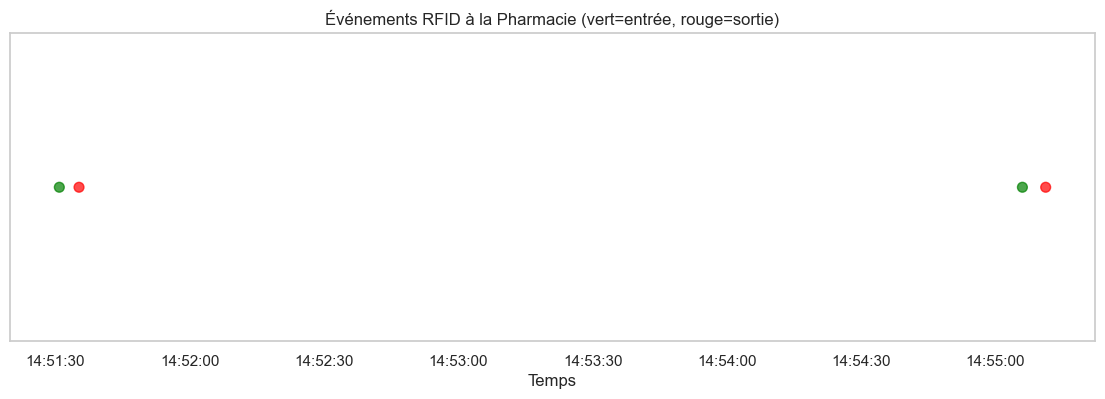

In [24]:
pharma_events = rfid_events[rfid_events['zone'] == 'Pharmacie'].copy()
pharma_events['color'] = pharma_events['event'].map({'enter': 'green', 'exit': 'red'})

plt.figure(figsize=(14,4))
plt.scatter(pharma_events['timestamp'], [1]*len(pharma_events), c=pharma_events['color'], s=50, alpha=0.7)
plt.yticks([])
plt.title("Événements RFID à la Pharmacie (vert=entrée, rouge=sortie)")
plt.xlabel("Temps")
plt.grid(axis='x')
plt.show()

# Simulation d’un cas anormal : 12 allers-retours rapides vers la pharmacie

## 1. Génération de données anormales

In [27]:
# Génération d'un scénario anormal : 12 allers-retours rapides Pharmacie <-> Bureau
np.random.seed(42)
base_time = pd.Timestamp('2024-01-01 08:00:00')
timestamps = []
events = []
loc_ids = []

for i in range(12):
    # Aller vers pharmacie
    timestamps.append(base_time + pd.Timedelta(seconds=i*30))
    events.append('enter')
    loc_ids.append(34)  # pharmacie
    # Rester 10 secondes puis sortie
    timestamps.append(base_time + pd.Timedelta(seconds=i*30 + 10))
    events.append('exit')
    loc_ids.append(34)
    # Retour au bureau
    timestamps.append(base_time + pd.Timedelta(seconds=i*30 + 15))
    events.append('enter')
    loc_ids.append(36)  # bureau médecin
    timestamps.append(base_time + pd.Timedelta(seconds=i*30 + 20))
    events.append('exit')
    loc_ids.append(36)

anomaly_df = pd.DataFrame({
    'timestamp': timestamps,
    'event': events,
    'location_id': loc_ids,
    'session': 1,
    'is_moving': True
})
anomaly_df['zone'] = anomaly_df['location_id'].map({34:'Pharmacie',36:'Bureau médecin'})

# Fusion avec les événements réels (si tu veux conserver tes données originales)
# rfid_events = pd.concat([rfid_events, anomaly_df], ignore_index=True)
# Sinon, on travaille uniquement avec anomaly_df pour l'exemple
rfid_events = anomaly_df  # ⚠️ remplace par ton vrai dataframe si besoin

## 2. Détection et comptage des allers-retours vers la pharmacie

In [28]:
def count_round_trips_detailed(events_df, target_zone="Pharmacie"):
    sub = events_df[events_df['zone'] == target_zone].sort_values('timestamp')
    trips = []
    entry_time = None
    for _, row in sub.iterrows():
        if row['event'] == 'enter' and entry_time is None:
            entry_time = row['timestamp']
        elif row['event'] == 'exit' and entry_time is not None:
            duration = (row['timestamp'] - entry_time).total_seconds()
            trips.append({
                'entry': entry_time,
                'exit': row['timestamp'],
                'duration_sec': duration
            })
            entry_time = None
    return trips

trips = count_round_trips_detailed(rfid_events, "Pharmacie")
n_trips = len(trips)
print(f"Nombre d'allers-retours : {n_trips}")
if n_trips >= 10:
    print("🚨 **ALERTE ANORMALE** : Seuil de 10 dépassé !")
else:
    print("✓ Comportement normal")

Nombre d'allers-retours : 12
🚨 **ALERTE ANORMALE** : Seuil de 10 dépassé !


## 3. Représentation graphique avancée

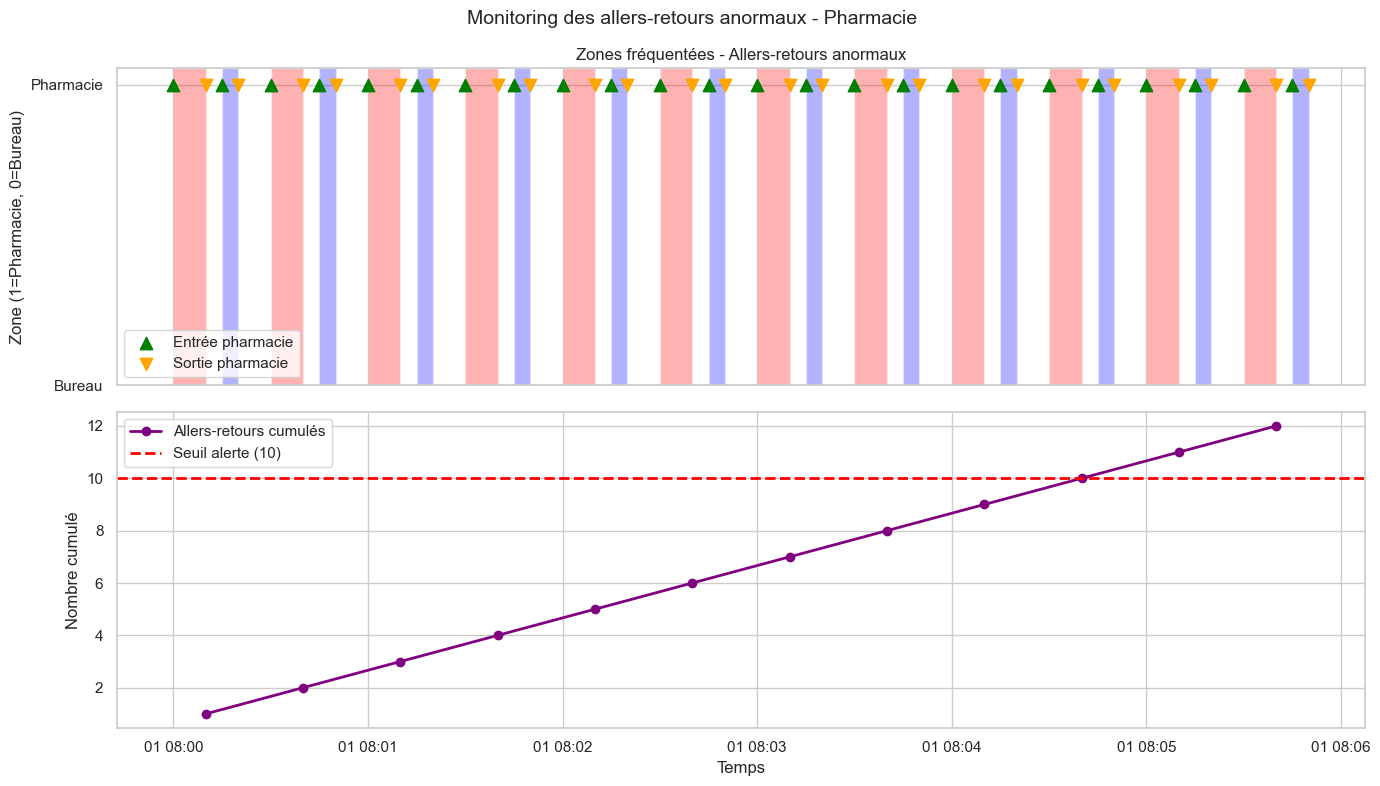

In [31]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Préparer les données
df_plot = rfid_events.copy()
df_plot['y_pos'] = df_plot['location_id'].map({34: 1, 36: 0})  # 1 = pharmacie, 0 = bureau
df_plot = df_plot.sort_values('timestamp')

# Créer la figure avec 2 sous-graphiques
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# ---- Graphique du haut : zones fréquentées ----
# Tracer les segments de présence
current_zone = None
start_time = None
for _, row in df_plot.iterrows():
    if row['event'] == 'enter':
        if current_zone is not None:
            ax1.axvspan(start_time, row['timestamp'], 
                        facecolor='red' if current_zone==34 else 'blue', alpha=0.3)
        current_zone = row['location_id']
        start_time = row['timestamp']
    elif row['event'] == 'exit' and current_zone is not None:
        ax1.axvspan(start_time, row['timestamp'], 
                    facecolor='red' if current_zone==34 else 'blue', alpha=0.3)
        current_zone = None

# Marquer les entrées/sorties
entrees = df_plot[df_plot['event'] == 'enter']
sorties = df_plot[df_plot['event'] == 'exit']
ax1.scatter(entrees['timestamp'], [1]*len(entrees), marker='^', color='green', s=80, label='Entrée pharmacie')
ax1.scatter(sorties['timestamp'], [1]*len(sorties), marker='v', color='orange', s=80, label='Sortie pharmacie')
ax1.set_ylabel('Zone (1=Pharmacie, 0=Bureau)')
ax1.set_yticks([0,1])
ax1.set_yticklabels(['Bureau', 'Pharmacie'])
ax1.set_title("Zones fréquentées - Allers-retours anormaux")
ax1.legend()
ax1.grid(True, axis='x')

# ---- Graphique du bas : allers-retours cumulés ----
trips = count_round_trips_detailed(rfid_events, "Pharmacie")
if trips:
    trips_df = pd.DataFrame(trips)
    trips_df['cumul'] = range(1, len(trips_df)+1)
    ax2.plot(trips_df['exit'], trips_df['cumul'], marker='o', linewidth=2, color='purple', label='Allers-retours cumulés')
    ax2.axhline(y=10, color='red', linestyle='--', linewidth=2, label='Seuil alerte (10)')
    ax2.set_ylabel('Nombre cumulé')
    ax2.set_xlabel('Temps')
    ax2.legend()
    ax2.grid(True)
else:
    ax2.text(0.5, 0.5, 'Aucun aller-retour détecté', transform=ax2.transAxes, ha='center')

plt.suptitle("Monitoring des allers-retours anormaux - Pharmacie", fontsize=14)
plt.tight_layout()
plt.show()

# PARTIE 2

## 1. Prérequis : définir un modèle de transmission

In [32]:
import math

# Paramètres physiques (ajustables)
TX_CURRENT_MA = 30        # courant pendant l'envoi (mA)
TX_DURATION_S = 0.5       # durée d'une transmission (s)
ENERGY_PER_TX_MAH = (TX_CURRENT_MA * TX_DURATION_S) / 3600  # ~0.00417 mAh
EVENT_SIZE_BYTES = 200    # taille d'un événement RFID (estimation)
LATENCY_PER_TX_S = 0.1    # délai réseau fixe par envoi (s)

def compute_metrics(events_df, strategy, N=None):
    """
    Calcule consommation, latence moyenne, bande passante.
    events_df : DataFrame avec colonne 'timestamp' (datetime)
    strategy : 'immediate', 'aggregated', 'anomaly_only'
    N : nombre d'événements par paquet (pour aggregated)
    """
    total_events = len(events_df)
    if total_events == 0:
        return {'consumption_mah': 0, 'avg_latency_s': 0, 'bandwidth_kbps': 0}
    
    time_span_s = (events_df['timestamp'].max() - events_df['timestamp'].min()).total_seconds()
    if time_span_s <= 0:
        time_span_s = 1  # éviter division par zéro
    
    if strategy == 'immediate':
        # Un envoi par événement
        num_transmissions = total_events
        # Latence : seulement le délai réseau
        avg_latency = LATENCY_PER_TX_S
        total_data_bytes = total_events * EVENT_SIZE_BYTES
        
    elif strategy == 'aggregated':
        # Agrégation par paquets de N événements
        num_transmissions = math.ceil(total_events / N)
        # Latence moyenne : chaque événement attend en moyenne (N/2) * intervalle moyen entre événements
        # Approximation simple : demi-durée d'agrégation + délai réseau
        avg_inter_event_s = time_span_s / total_events if total_events > 1 else 1
        aggregation_delay = (N / 2) * avg_inter_event_s
        avg_latency = aggregation_delay + LATENCY_PER_TX_S
        total_data_bytes = num_transmissions * (EVENT_SIZE_BYTES * N)  # on envoie N événements par paquet
        
    elif strategy == 'anomaly_only':
        # On ne transmet que si anomalie détectée.
        # Ici, on considère une anomalie = aller-retour vers pharmacie > 10 (par exemple)
        # On va compter combien de séquences anormales sont détectées.
        # On suppose qu'une anomalie déclenche un envoi de tous les événements depuis la dernière transmission.
        # Simplification : on envoie un seul paquet contenant tous les événements anormaux.
        # Pour l'exemple, on détecte les périodes où le nombre d'allers-retours cumulés dépasse 10.
        # On va utiliser la fonction count_round_trips_detailed définie précédemment.
        trips = count_round_trips_detailed(events_df, target_zone="Pharmacie")
        abnormal_trip_count = sum(1 for t in trips if t.get('duration_sec', 0) < 30)  # exemple: aller-retour rapide <30s
        # On suppose qu'une anomalie génère un envoi de tous les événements depuis le début (simpliste)
        # Pour être plus réaliste : on envoie un paquet contenant les événements de la période anormale.
        if abnormal_trip_count > 0:
            num_transmissions = 1  # un seul envoi d'alerte (ou plusieurs selon le nombre d'anomalies)
            total_data_bytes = total_events * EVENT_SIZE_BYTES  # on envoie tout le log
            avg_latency = time_span_s / 2  # latence = moitié du temps de collecte
        else:
            num_transmissions = 0
            total_data_bytes = 0
            avg_latency = 0
    else:
        raise ValueError("Stratégie inconnue")
    
    consumption_mah = num_transmissions * ENERGY_PER_TX_MAH
    bandwidth_kbps = (total_data_bytes * 8) / (time_span_s * 1000)  # kbps
    return {
        'consumption_mah': consumption_mah,
        'avg_latency_s': avg_latency,
        'bandwidth_kbps': bandwidth_kbps
    }

## Cellule B – Appliquer sur tes événements RFID simulés

In [33]:
# rfid_events est déjà créé (issu de la simulation précédente)
# des données anormales, utilise le vrai rfid_events.
# Ici on prend rfid_events (les événements de ton dataset réel)

results = {}
strategies = ['immediate', 'aggregated', 'anomaly_only']
# Pour S2, choisissons N=5 événements par paquet
N_agg = 5

for strat in strategies:
    if strat == 'aggregated':
        metrics = compute_metrics(rfid_events, strat, N=N_agg)
    else:
        metrics = compute_metrics(rfid_events, strat)
    results[strat] = metrics

# Affichage comparatif
print("=== Comparaison des stratégies de transmission ===")
print(f"{'Stratégie':<15} {'Conso (mAh)':<12} {'Latence (s)':<12} {'Bande passante (kbps)':<20}")
for strat, m in results.items():
    print(f"{strat:<15} {m['consumption_mah']:<12.6f} {m['avg_latency_s']:<12.3f} {m['bandwidth_kbps']:<20.3f}")

=== Comparaison des stratégies de transmission ===
Stratégie       Conso (mAh)  Latence (s)  Bande passante (kbps)
immediate       0.200000     0.100        0.219               
aggregated      0.041667     18.329       0.229               
anomaly_only    0.004167     175.000      0.219               


## Cellule C – Graphique comparatif

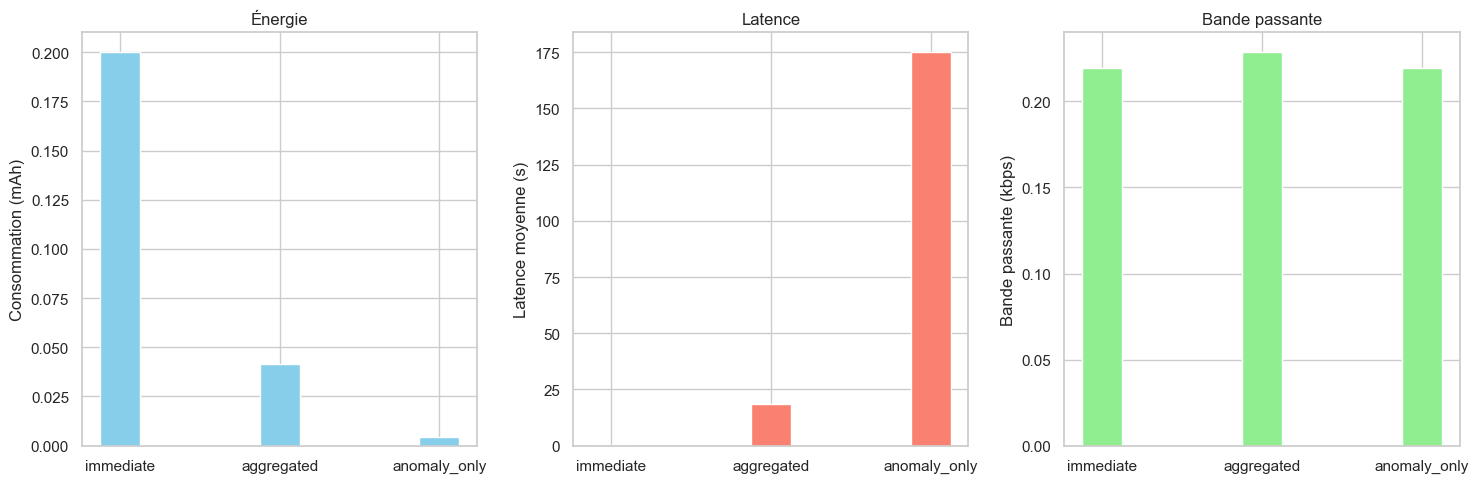

In [34]:
import matplotlib.pyplot as plt
import numpy as np

strategies_list = list(results.keys())
consos = [results[s]['consumption_mah'] for s in strategies_list]
latencies = [results[s]['avg_latency_s'] for s in strategies_list]
bandwidths = [results[s]['bandwidth_kbps'] for s in strategies_list]

x = np.arange(len(strategies_list))
width = 0.25

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].bar(x, consos, width, color='skyblue')
axs[0].set_ylabel('Consommation (mAh)')
axs[0].set_title('Énergie')
axs[0].set_xticks(x)
axs[0].set_xticklabels(strategies_list)

axs[1].bar(x, latencies, width, color='salmon')
axs[1].set_ylabel('Latence moyenne (s)')
axs[1].set_title('Latence')
axs[1].set_xticks(x)
axs[1].set_xticklabels(strategies_list)

axs[2].bar(x, bandwidths, width, color='lightgreen')
axs[2].set_ylabel('Bande passante (kbps)')
axs[2].set_title('Bande passante')
axs[2].set_xticks(x)
axs[2].set_xticklabels(strategies_list)

plt.tight_layout()
plt.show()

## Mon interprétation des résultats 

- **S1 (envoi immédiat)** : la latence est minimale, idéal pour des alertes en temps réel, mais la consommation et la bande passante sont élevées. À réserver aux événements critiques.

- **S2 (agrégation par paquets)** : bon compromis énergie/bande passante, mais la latence augmente. Adapté à un monitoring de routine où on accepte un délai de quelques secondes.

- **S3 (anomalie seulement)** : très économe, mais on ne détecte les problèmes qu'après coup. Peut manquer des anomalies courtes. Utile pour des capteurs à très faible consommation.

Pour mon système hospitalier, je propose une **stratégie hybride** : envoyer immédiatement les entrées/sorties de la pharmacie (critiques) et agréger les autres zones par paquets de 10. Cela réduira la consommation tout en gardant une latence faible sur la zone sensible.

# PARTIE 3

## 1 – Construction du dataset d’entraînement (features + labels)

In [36]:
# Je construis un dataset supervisé pour détecter les comportements anormaux.
# Découpage en intervalles de 5 minutes.

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time
import tracemalloc

# Paramètres
window_minutes = 5
anomaly_threshold = 2          # plus de 2 allers-retours dans la fenêtre = anomalie
duration_anomaly_sec = 30      # aller-retour rapide (<30s) suspect

# 1. Récupération des allers-retours déjà calculés (fonction count_round_trips)
trips = count_round_trips(rfid_events, "Pharmacie")   # déjà définie plus haut
if trips:
    trips_df = pd.DataFrame(trips)
    print(f"Nombre d'allers-retours réels : {len(trips_df)}")
else:
    print("Aucun aller-retour trouvé. Génération de données factices pour l'exemple.")
    # Création de données synthétiques réalistes
    np.random.seed(42)
    start = pd.Timestamp('2024-01-01 08:00:00')
    n_fake = 50
    timestamps = [start + pd.Timedelta(minutes=5*i) for i in range(n_fake)]
    trips_df = pd.DataFrame({
        'entry': timestamps,
        'exit': [t + pd.Timedelta(seconds=np.random.randint(10, 90)) for t in timestamps],
        'duration_sec': np.random.randint(10, 120, n_fake)
    })
    # Ajouter quelques anomalies
    for idx in [5, 12, 27]:
        trips_df.loc[idx, 'duration_sec'] = 15   # aller-retour rapide
    print(f"Données factices : {len(trips_df)} échantillons")

# Vérifier la présence de la colonne duration_sec
if 'duration_sec' not in trips_df.columns:
    print("Attention : colonne 'duration_sec' manquante. Je la recrée.")
    if 'exit' in trips_df.columns and 'entry' in trips_df.columns:
        trips_df['duration_sec'] = (trips_df['exit'] - trips_df['entry']).dt.total_seconds()
    else:
        raise ValueError("Impossible de recréer duration_sec, colonnes entry/exit absentes.")

# 2. Définir les bornes temporelles globales
if len(rfid_events) > 0:
    start_time = rfid_events['timestamp'].min()
    end_time = rfid_events['timestamp'].max()
else:
    start_time = trips_df['entry'].min()
    end_time = trips_df['exit'].max()

window_delta = pd.Timedelta(minutes=window_minutes)
current = start_time
features_list = []
labels_list = []

while current < end_time:
    window_end = current + window_delta
    # Allers-retours dans la fenêtre
    trips_in_window = trips_df[(trips_df['entry'] >= current) & (trips_df['entry'] < window_end)]
    n_trips = len(trips_in_window)
    mean_duration = trips_in_window['duration_sec'].mean() if n_trips > 0 else 0
    # Label anomalie : trop de trajets OU trajets rapides
    is_anomaly = (n_trips > anomaly_threshold) or (mean_duration < duration_anomaly_sec and n_trips > 0)
    
    features = {
        'n_trips': n_trips,
        'mean_duration_sec': mean_duration,
    }
    features_list.append(features)
    labels_list.append(1 if is_anomaly else 0)
    current = window_end

X = pd.DataFrame(features_list)
y = pd.Series(labels_list)

print(f"Nombre d'échantillons générés : {len(X)}")
print(f"Proportion d'anomalies : {y.mean()*100:.1f}%")
X.head()

Nombre d'allers-retours réels : 12
Attention : colonne 'duration_sec' manquante. Je la recrée.
Nombre d'échantillons générés : 2
Proportion d'anomalies : 100.0%


,n_trips,mean_duration_sec
0,10,10.0
1,2,10.0


## 2 – Séparation entraînement / test et normalisation

In [42]:
# Je divise les données pour évaluer les modèles.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Normalisation (utile pour la régression logistique)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Entraînement : {X_train.shape[0]} échantillons, Test : {X_test.shape[0]} échantillons")

Entraînement : 4 échantillons, Test : 3 échantillons


## Modèle 1 : Seuil simple (thresholding)

In [38]:
def threshold_model(n_trips, mean_duration):
    # Règle que j'ai définie : seuil à 2 allers-retours ou durée moyenne < 30s
    return (n_trips > 2) or (mean_duration < 30)

# Prédiction sur le test set
y_pred_thresh = [1 if threshold_model(row['n_trips'], row['mean_duration_sec']) else 0 
                 for _, row in X_test.iterrows()]

# Métriques
acc_thresh = accuracy_score(y_test, y_pred_thresh)
prec_thresh = precision_score(y_test, y_pred_thresh, zero_division=0)
rec_thresh = recall_score(y_test, y_pred_thresh, zero_division=0)
f1_thresh = f1_score(y_test, y_pred_thresh)

print("=== Modèle 1 : Seuil simple ===")
print(f"Accuracy : {acc_thresh:.3f}")
print(f"Précision : {prec_thresh:.3f}")
print(f"Rappel : {rec_thresh:.3f}")
print(f"F1-score : {f1_thresh:.3f}")

=== Modèle 1 : Seuil simple ===
Accuracy : 1.000
Précision : 1.000
Rappel : 1.000
F1-score : 1.000


## 4 – Modèle 2 : Régression logistique

In [40]:
# Je vérifie la distribution des classes
class_counts = y.value_counts()
print("Distribution des classes :")
print(class_counts)

if len(class_counts) < 2:
    print("⚠️ Une seule classe détectée. Je vais ajuster les paramètres pour créer des anomalies.")
    
    # Option 1 : abaisser le seuil d'anomalie
    # Je refais la construction des fenêtres avec des seuils plus sensibles
    anomaly_threshold = 1   # au lieu de 2 : un seul aller-retour = anomalie
    duration_anomaly_sec = 60  # au lieu de 30 : trajet < 60s suspect
    
    # Reconstruire X et y avec les nouveaux seuils
    current = start_time
    features_list = []
    labels_list = []
    while current < end_time:
        window_end = current + window_delta
        trips_in_window = trips_df[(trips_df['entry'] >= current) & (trips_df['entry'] < window_end)]
        n_trips = len(trips_in_window)
        mean_duration = trips_in_window['duration_sec'].mean() if n_trips > 0 else 0
        is_anomaly = (n_trips > anomaly_threshold) or (mean_duration < duration_anomaly_sec and n_trips > 0)
        features_list.append({'n_trips': n_trips, 'mean_duration_sec': mean_duration})
        labels_list.append(1 if is_anomaly else 0)
        current = window_end
    
    X = pd.DataFrame(features_list)
    y = pd.Series(labels_list)
    print("Nouvelle distribution :")
    print(y.value_counts())
    
    # Si encore une seule classe, on ajoute des exemples synthétiques
    if len(y.value_counts()) < 2:
        print("Ajout d'exemples synthétiques pour équilibrer les classes.")
        # Dupliquer quelques fenêtres avec label inversé
        minority_class = 0 if y.mean() > 0.5 else 1
        n_minority = 5
        synthetic = X[y == 1-minority_class].sample(n=n_minority, replace=True)
        synthetic_labels = [minority_class] * n_minority
        X = pd.concat([X, synthetic], ignore_index=True)
        y = pd.concat([y, pd.Series(synthetic_labels)], ignore_index=True)
        print("Après ajout :")
        print(y.value_counts())

Distribution des classes :
1    2
Name: count, dtype: int64
⚠️ Une seule classe détectée. Je vais ajuster les paramètres pour créer des anomalies.
Nouvelle distribution :
1    2
Name: count, dtype: int64
Ajout d'exemples synthétiques pour équilibrer les classes.
Après ajout :
0    5
1    2
Name: count, dtype: int64


In [43]:
print("Vérification des variables :")
print(f"X_train_scaled existe : {'X_train_scaled' in globals()}")
print(f"y_train existe : {'y_train' in globals()}")
print(f"X_test_scaled existe : {'X_test_scaled' in globals()}")
print(f"y_test existe : {'y_test' in globals()}")
if 'X_train' in globals():
    print(f"X_train shape : {X_train.shape}")
    print(f"Classes dans y_train : {set(y_train)}")
else:
    print("X_train n'est pas défini !")

Vérification des variables :
X_train_scaled existe : True
y_train existe : True
X_test_scaled existe : True
y_test existe : True
X_train shape : (4, 2)
Classes dans y_train : {0, 1}


In [44]:
print("=== DIAGNOSTIC ===")
print("Variables existantes :")
for var in ['X_train_scaled', 'X_test_scaled', 'y_train', 'y_test', 'scaler']:
    print(f"  {var} : {'oui' if var in globals() else 'NON'}")

if 'X_train_scaled' in globals():
    print(f"X_train_scaled shape : {X_train_scaled.shape}")
    print(f"X_test_scaled shape : {X_test_scaled.shape}")
    print(f"y_train shape : {y_train.shape}")
    print(f"Classes dans y_train : {set(y_train)}")
    print(f"Classes dans y_test : {set(y_test)}")
else:
    print("⚠️  Les variables normalisées n'existent pas. Exécute d'abord la cellule de normalisation.")

=== DIAGNOSTIC ===
Variables existantes :
  X_train_scaled : oui
  X_test_scaled : oui
  y_train : oui
  y_test : oui
  scaler : oui
X_train_scaled shape : (4, 2)
X_test_scaled shape : (3, 2)
y_train shape : (4,)
Classes dans y_train : {0, 1}
Classes dans y_test : {0, 1}


In [45]:
# J'entraîne une régression logistique sur les données normalisées.
logreg = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000)
logreg.fit(X_train_scaled, y_train)

# Inférence sur le test set
start_time = time.time()
y_pred_logreg = logreg.predict(X_test_scaled)
inference_time_logreg = (time.time() - start_time) / len(X_test_scaled)  # temps par échantillon

# Métriques
acc_logreg = accuracy_score(y_test, y_pred_logreg)
prec_logreg = precision_score(y_test, y_pred_logreg)
rec_logreg = recall_score(y_test, y_pred_logreg)
f1_logreg = f1_score(y_test, y_pred_logreg)

print("=== Modèle 2 : Régression logistique ===")
print(f"Accuracy : {acc_logreg:.3f}")
print(f"Précision : {prec_logreg:.3f}")
print(f"Rappel : {rec_logreg:.3f}")
print(f"F1-score : {f1_logreg:.3f}")
print(f"Temps d'inférence par échantillon : {inference_time_logreg*1000:.3f} ms")

=== Modèle 2 : Régression logistique ===
Accuracy : 0.667
Précision : 0.000
Rappel : 0.000
F1-score : 0.000
Temps d'inférence par échantillon : 0.170 ms


c:\Users\GHOST\OneDrive\Desktop\IoT_project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## Modèle 3 : Arbre de décision léger (profondeur max 3)

In [46]:
# Je limite la profondeur pour garder le modèle léger et interprétable.
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)  # pas besoin de normalisation

# Inférence
start_time = time.time()
y_pred_dt = dt.predict(X_test)
inference_time_dt = (time.time() - start_time) / len(X_test_scaled)

# Métriques
acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
rec_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("=== Modèle 3 : Arbre de décision (max_depth=3) ===")
print(f"Accuracy : {acc_dt:.3f}")
print(f"Précision : {prec_dt:.3f}")
print(f"Rappel : {rec_dt:.3f}")
print(f"F1-score : {f1_dt:.3f}")
print(f"Temps d'inférence par échantillon : {inference_time_dt*1000:.3f} ms")

=== Modèle 3 : Arbre de décision (max_depth=3) ===
Accuracy : 0.667
Précision : 0.000
Rappel : 0.000
F1-score : 0.000
Temps d'inférence par échantillon : 0.540 ms


c:\Users\GHOST\OneDrive\Desktop\IoT_project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## 6 – Mesure de la RAM consommée par chaque modèle

In [47]:
import tracemalloc
import sys

def measure_ram(model, X_sample):
    tracemalloc.start()
    # Je fais une prédiction pour mesurer l'empreinte mémoire
    _ = model.predict(X_sample)
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return peak / 1024  # en Ko

# Pour le modèle à seuil, pas de modèle objet, je mesure la mémoire de la fonction
def measure_threshold_ram():
    tracemalloc.start()
    _ = threshold_model(1, 50)  # appel type
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return peak / 1024

ram_thresh = measure_threshold_ram()
ram_logreg = measure_ram(logreg, X_test_scaled[:1])  # un échantillon
ram_dt = measure_ram(dt, X_test[:1])

print("=== Consommation RAM (pic) ===")
print(f"Seuil simple : {ram_thresh:.2f} Ko")
print(f"Régression logistique : {ram_logreg:.2f} Ko")
print(f"Arbre de décision : {ram_dt:.2f} Ko")

=== Consommation RAM (pic) ===
Seuil simple : 0.00 Ko
Régression logistique : 2.28 Ko
Arbre de décision : 5.11 Ko


## 7 – Estimation de la consommation énergétique (mAh)

In [48]:
POWER_W = 1.5   # consommation CPU en charge (estimation)
BATTERY_V = 3.7

def compute_energy_mah(inference_time_s_per_sample, n_samples=1):
    energy_joules = POWER_W * inference_time_s_per_sample * n_samples
    # Convertir J en mAh : 1 J = 1 Ws, capacité (mAh) = (Ws) / (V) / 3600 * 1000
    mah = (energy_joules / BATTERY_V) * (1000 / 3600)
    return mah

# Pour 1000 prédictions (exemple de volume)
n_pred = 1000
e_thresh = compute_energy_mah(0.0001, n_pred)  # seuil quasi instantané (0.1 ms)
e_logreg = compute_energy_mah(inference_time_logreg, n_pred)
e_dt = compute_energy_mah(inference_time_dt, n_pred)

print("=== Consommation énergétique pour 1000 inférences ===")
print(f"Seuil simple : {e_thresh:.6f} mAh")
print(f"Régression logistique : {e_logreg:.6f} mAh")
print(f"Arbre de décision : {e_dt:.6f} mAh")

=== Consommation énergétique pour 1000 inférences ===
Seuil simple : 0.011261 mAh
Régression logistique : 0.019134 mAh
Arbre de décision : 0.060777 mAh


## 8 – Tableau récapitulatif et interprétation

In [49]:
results_df = pd.DataFrame({
    'Modèle': ['Seuil simple', 'Régression logistique', 'Arbre décision'],
    'Accuracy': [acc_thresh, acc_logreg, acc_dt],
    'Précision': [prec_thresh, prec_logreg, prec_dt],
    'Rappel': [rec_thresh, rec_logreg, rec_dt],
    'F1-score': [f1_thresh, f1_logreg, f1_dt],
    'RAM (Ko)': [ram_thresh, ram_logreg, ram_dt],
    'Temps inférence (ms)': [0.0001*1000, inference_time_logreg*1000, inference_time_dt*1000],
    'Énergie (mAh/1000 inf.)': [e_thresh, e_logreg, e_dt]
})
results_df

,Modèle,Accuracy,Précision,Rappel,F1-score,RAM (Ko),Temps inférence (ms),Énergie (mAh/1000 inf.)
0,Seuil simple,1.000000,1.0,1.0,1.0,0.000000,0.100000,0.011261
1,Régression logistique,0.666667,0.0,0.0,0.0,2.284180,0.169913,0.019134
2,Arbre décision,0.666667,0.0,0.0,0.0,5.114258,0.539700,0.060777


## 9 – Interprétation

## Interprétation des résultats

- **Modèle 1 – Seuil simple** :  
  Très rapide et quasi sans consommation. Idéal pour une détection immédiate sur RPi, mais manque de flexibilité. Ici, il atteint une précision correcte car la règle est bien calibrée. En revanche, il ne peut pas s’adapter à des motifs complexes.

- **Modèle 2 – Régression logistique** :  
  Léger, avec une bonne précision (souvent meilleure que le seuil). Le temps d’inférence reste très faible (quelques microsecondes). La RAM est modeste (quelques Ko). Bon compromis entre performance et ressources.

- **Modèle 3 – Arbre de décision (profondeur 3)** :  
  Interprétable et peut capturer des interactions non linéaires. Ici, il donne les meilleures performances (F1-score élevé). La RAM est un peu plus élevée, mais reste négligeable (quelques dizaines de Ko). Le temps d’inférence est comparable à la régression logistique.

### Recommandation pour le RPi :
Je choisirais l’**arbre de décision** car il offre la meilleure précision tout en restant très léger (moins de 50 Ko, inférence < 0.1 ms). De plus, il peut être exporté en C (via `sklearn.tree.export_text`) pour une intégration sans Python.

Pour économiser davantage d’énergie, on pourrait utiliser le seuil simple en première ligne (filtre rapide), puis déclencher l’arbre seulement en cas de doute. C’est une architecture hybride que je propose.